## 07 Xenium Epithelial Niche Features

**What this notebook does:** Identifies ductal epithelial spatial components in Xenium data, extracts DAPI-based morphology features, builds cell graphs, summarizes niche-level features, and scores PDAC pathology modules.

**Data files needed:**
- `data/xenium_pancreas_10x/annotated_h5ad/` (from notebook 07_xenium_01)
- Raw Xenium DAPI images (on external drive)

**How to run:** Run notebooks 07_xenium_00 and 07_xenium_01 first.

In [1]:
from pathlib import Path
# DATA AVAILABILITY CHECK
import os
# Epithelial niche features requires annotated Xenium data
_output_dir = Path("/Users/shihongwu/SpatioEv") / "data" / "xenium_pancreas_10x"
_annotated_dir = _output_dir / "annotated_h5ad"
_required_files = [_output_dir, _annotated_dir]
_missing = [f for f in _required_files if not os.path.exists(f)]
if _missing:
    print(f'Missing required data files: {_missing}')
    print('   This notebook requires real experimental data to run.')
    print('   The code is shown for reference.')
else:
    print('All required data files found. Notebook is ready to run.')


All required data files found. Notebook is ready to run.


# Xenium Epithelial Niche Feature Construction

This notebook turns annotated Xenium cells into epithelial-centered niches.

The key design choice is to define a niche as a connected spatial component of cells annotated as `pancreatic ductal epithelium`.

For Xenium, the preferred component definition uses the 10x cell-boundary polygons: two epithelial cells are connected when their segmentation boundaries touch or are within a small gap. This is closer to the multiplexed-imaging mask-adjacency logic than a centroid-radius rule. A centroid fallback is still available when boundary files are missing or too slow.

Then we summarize:

- epithelial niche geometry/topology
- epithelial expression/state features
- surrounding Tier_A/Tier_B composition
- compartment-specific marker changes in the local surround

Feature guardrail:

The current Xenium trajectory can capture epithelial transcript state, nuclear/cell shape from segmentation boundaries, optional DAPI texture/intensity, tissue architecture, and microenvironment context. It still cannot reproduce CK19/NaKATPase membrane polarity unless aligned protein imaging is available.


In [2]:

%matplotlib inline

import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba")

from pathlib import Path
import gc
import json
import importlib.util
import tarfile
import warnings
from io import StringIO

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 8
sns.set_style("white")

ROOT = Path("/Users/shihongwu/SpatioEv")
DATA_ROOT = Path("/Volumes/Shihong_5/for_spatioev/pancreas_Xenium_example_data_from_10X")
OUTPUT_DIR = ROOT / "data" / "xenium_pancreas_10x"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_CONFIGS = [
    {
        "sample_id": "pdac_pancreas_v1",
        "display_name": "Human Pancreas FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Multi-Tissue and Cancer",
        "outs_path": DATA_ROOT / "Xenium_V1_human_Pancreas_FFPE_outs",
    },
    {
        "sample_id": "pdac_io_v1",
        "display_name": "Human Ductal Adenocarcinoma FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Immuno-Oncology",
        "outs_path": DATA_ROOT / "Xenium_V1_Human_Ductal_Adenocarcinoma_FFPE_outs",
    },
    {
        "sample_id": "pdac_addon_v1",
        "display_name": "hPancreas Cancer Add-on FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Multi-Tissue + Add-on",
        "outs_path": DATA_ROOT / "Xenium_V1_hPancreas_Cancer_Add_on_FFPE_outs",
    },
    {
        "sample_id": "normal_nondiseased_v1",
        "display_name": "hPancreas nondiseased section",
        "disease_group": "NormalPancreas",
        "panel_hint": "Human Multi-Tissue and Cancer",
        "outs_path": DATA_ROOT / "Xenium_V1_hPancreas_nondiseased_section_outs",
    },
]

CLINICAL_SAMPLE_METADATA = {
    "normal_nondiseased_v1": {
        "clinical_diagnosis": "Nondiseased pancreas",
        "clinical_stage": "Normal",
        "clinical_grade": "Normal",
        "clinical_grade_order": 0.0,
        "tumor_content_percent": 0.0,
        "clinical_progression_label": "Normal pancreas",
        "clinical_progression_order": 0,
        "clinical_note": "10x nondiseased pancreas reference",
    },
    "pdac_addon_v1": {
        "clinical_diagnosis": "Adenocarcinoma",
        "clinical_stage": "Not provided",
        "clinical_grade": "Grade I-II",
        "clinical_grade_order": 1.5,
        "tumor_content_percent": 50.0,
        "clinical_progression_label": "Grade I-II, 50% tumor",
        "clinical_progression_order": 1,
        "clinical_note": "10x pancreas cancer add-on sample; adenocarcinoma, Grade I-II, 50% tumor",
    },
    "pdac_pancreas_v1": {
        "clinical_diagnosis": "Adenocarcinoma",
        "clinical_stage": "Stage III",
        "clinical_grade": "Not provided",
        "clinical_grade_order": np.nan,
        "tumor_content_percent": np.nan,
        "clinical_progression_label": "Stage III adenocarcinoma",
        "clinical_progression_order": 2,
        "clinical_note": "10x human pancreas FFPE sample; Stage III adenocarcinoma",
    },
    "pdac_io_v1": {
        "clinical_diagnosis": "Pancreatic ductal adenocarcinoma",
        "clinical_stage": "Stage IIB",
        "clinical_grade": "Grade 3",
        "clinical_grade_order": 3.0,
        "tumor_content_percent": np.nan,
        "clinical_progression_label": "Stage IIB, Grade 3 PDAC",
        "clinical_progression_order": 3,
        "clinical_note": "10x human ductal adenocarcinoma FFPE sample; Stage IIB, Grade 3",
    },
}

CLINICAL_SAMPLE_ORDER = [
    "normal_nondiseased_v1",
    "pdac_addon_v1",
    "pdac_pancreas_v1",
    "pdac_io_v1",
]
CLINICAL_LABEL_ORDER = [
    CLINICAL_SAMPLE_METADATA[sample_id]["clinical_progression_label"]
    for sample_id in CLINICAL_SAMPLE_ORDER
]
CLINICAL_PALETTE = {
    "Normal pancreas": "#4daf4a",
    "Grade I-II, 50% tumor": "#ffb000",
    "Stage III adenocarcinoma": "#e41a1c",
    "Stage IIB, Grade 3 PDAC": "#6a3d9a",
}

def clinical_metadata_frame():
    return (
        pd.DataFrame.from_dict(CLINICAL_SAMPLE_METADATA, orient="index")
        .rename_axis("sample_id")
        .reset_index()
        .sort_values("clinical_progression_order")
    )

def attach_clinical_metadata(df):
    meta = clinical_metadata_frame()
    existing_meta_cols = [col for col in meta.columns if col != "sample_id" and col in df.columns]
    if existing_meta_cols:
        df = df.drop(columns=existing_meta_cols)
    return df.merge(meta, on="sample_id", how="left", validate="many_to_one")

def package_available(name):
    return importlib.util.find_spec(name) is not None

def save_df(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix == ".pkl":
        df.to_pickle(path)
    else:
        df.to_csv(path, index=index)

def load_df(path):
    path = Path(path)
    if path.suffix == ".pkl":
        return pd.read_pickle(path)
    return pd.read_csv(path)

def present_columns(df, cols):
    return [c for c in cols if c in df.columns]

def make_sparse_safe_copy(X):
    return X.copy() if sparse.issparse(X) else np.asarray(X).copy()


In [3]:

import spatioev as sv
from scipy.sparse.csgraph import connected_components
from spatioev.pp import extract_xenium_dapi_features

try:
    from shapely.geometry import Polygon
    from shapely.ops import unary_union
    from shapely.strtree import STRtree
    SHAPELY_AVAILABLE = True
except Exception as exc:
    SHAPELY_AVAILABLE = False
    SHAPELY_IMPORT_ERROR = repr(exc)

ANNOTATED_DIR = OUTPUT_DIR / "annotated_h5ad"
NICHE_DIR = OUTPUT_DIR / "niche_features"
NICHE_DIR.mkdir(exist_ok=True)
DAPI_FEATURE_DIR = OUTPUT_DIR / "dapi_features"
DAPI_FEATURE_DIR.mkdir(exist_ok=True)

NICHE_KEY = "xenium_ductal_epithelium_component"
NICHE_FEATURE_VERSION = "boundary_components_v3_lumen_continuity_interface"
EXPECTED_ANNOTATION_VERSION = "cluster_full_panel_v9_xenium_graphclust_io_mucosa_submucosa_k24"
EPITHELIAL_COMPONENT_METHOD = "boundary_proximity"
EPITHELIAL_BOUNDARY_GAP_UM = 3.0
EPITHELIAL_COMPONENT_RADIUS_UM = 35.0  # fallback only
CELL_GRAPH_RADIUS_UM = 35.0
SURROUND_HOPS = 5
MIN_NICHE_CELLS = 5
LUMEN_CLOSING_BUFFER_UM = 2.0
DUCT_CONTINUITY_RADIUS_UM = 150.0
BUDDING_DISTANCE_UM = 50.0
DAPI_TARGET_TIER_A = "pancreatic ductal epithelium"
DAPI_COMPUTE_TEXTURE = True
DAPI_COMPUTE_HARALICK = False
DAPI_FEATURE_VERSION = "user_verified_focus_dapi_sources_v2"

DAPI_IMAGE_SOURCE_OVERRIDES = {
    "pdac_pancreas_v1": {
        "relative_path": "morphology_focus/morphology_focus_0000.ome.tif",
        "image_kind": "verified_focus_dir0_channel0_dapi",
        "z_projection": "max",
        "channel_index": 0,
        "notes": "Use the first channel of morphology_focus/morphology_focus_0000.ome.tif as DAPI.",
    },
    "pdac_io_v1": {
        "relative_path": "morphology_focus/morphology_focus_0000.ome.tif",
        "image_kind": "verified_focus_dir0_dapi",
        "z_projection": "max",
        "channel_index": 0,
        "notes": "Use morphology_focus/morphology_focus_0000.ome.tif as DAPI.",
    },
    "pdac_addon_v1": {
        "relative_path": "morphology_focus.ome.tif",
        "image_kind": "verified_focus_dapi",
        "z_projection": "max",
        "channel_index": 0,
        "notes": "User-verified morphology_focus.ome.tif is the DAPI image.",
    },
    "normal_nondiseased_v1": {
        "relative_path": "morphology_focus.ome.tif",
        "image_kind": "verified_focus_dapi",
        "z_projection": "max",
        "channel_index": 0,
        "notes": "Use morphology_focus.ome.tif as DAPI.",
    },
}

PHENOTYPE_FEATURE_MAP_CANDIDATES = {
    "pancreatic ductal epithelium": [
        "EPCAM_expr_z", "KRT7_expr_z", "SOX9_expr_z", "MUC5AC_expr_z",
        "TFF2_expr_z", "TFF3_expr_z", "CEACAM6_expr_z", "AGR3_expr_z",
        "CFTR_expr_z", "FXYD2_expr_z", "TM4SF4_expr_z", "PROX1_expr_z",
        "MKI67_expr_z", "UBE2C_expr_z", "TOP2A_expr_z",
    ],
    "Duodenum epithelial": [
        "CDX2_expr_z", "REG4_expr_z", "DMBT1_expr_z", "TMPRSS2_expr_z",
        "MUC2_expr_z", "KRT20_expr_z", "VIL1_expr_z",
    ],
    "Fibroblasts": [
        "ACTA2_expr_z", "PDGFRA_expr_z", "FAP_expr_z", "THY1_expr_z",
        "PDPN_expr_z", "DCN_expr_z", "LUM_expr_z",
    ],
    "Endothelial cells": [
        "PECAM1_expr_z", "VWF_expr_z", "KDR_expr_z", "CDH5_expr_z",
        "PLVAP_expr_z", "FLT1_expr_z", "SPARCL1_expr_z", "IGFBP7_expr_z",
        "SOX17_expr_z", "CD34_expr_z",
    ],
    "T cells": ["CD3D_expr_z", "CD3E_expr_z", "CD4_expr_z", "CD8A_expr_z", "FOXP3_expr_z", "GZMB_expr_z", "NKG7_expr_z"],
    "B lineage": ["CD19_expr_z", "MS4A1_expr_z", "CD79A_expr_z", "MZB1_expr_z", "JCHAIN_expr_z", "SDC1_expr_z"],
    "Myeloid cells": [
        "LST1_expr_z", "LYZ_expr_z", "CD68_expr_z", "AIF1_expr_z", "C1QA_expr_z", "C1QB_expr_z",
        "CD163_expr_z", "MPEG1_expr_z", "CSF1R_expr_z", "S100A9_expr_z", "CXCR2_expr_z", "ITGAX_expr_z",
    ],
    "pancreatic acinar epithelium": [
        "AMY2A_expr_z", "PRSS1_expr_z", "CPA1_expr_z", "REG1A_expr_z",
        "AQP8_expr_z", "GATM_expr_z", "ANPEP_expr_z", "KLK11_expr_z",
    ],
    "Islets": ["INS_expr_z", "GCG_expr_z", "SST_expr_z", "PPY_expr_z", "CHGA_expr_z"],
}

STATE_FEATURE_CANDIDATES = sorted(
    set(
        [
            "cell_area",
            "nucleus_area",
            "nucleus_to_cell_area",
            "nucleus_to_cell_area_z",
            "cell_boundary_area",
            "cell_boundary_perimeter",
            "cell_boundary_circularity",
            "cell_boundary_solidity",
            "cell_boundary_major_minor_axis_ratio",
            "cell_boundary_feret_diameter_max",
            "cell_boundary_irregularity",
            "nucleus_boundary_area",
            "nucleus_boundary_perimeter",
            "nucleus_boundary_circularity",
            "nucleus_boundary_solidity",
            "nucleus_boundary_major_minor_axis_ratio",
            "nucleus_boundary_feret_diameter_max",
            "nucleus_boundary_irregularity",
            "dapi_n_pixels",
            "dapi_area_um2",
            "dapi_total_intensity_z",
            "dapi_mean_z",
            "dapi_std_z",
            "dapi_iqr_z",
            "dapi_entropy_z",
            "dapi_lacunarity_z",
            "dapi_polarity_score_z",
            "dapi_inertia_z",
            "transcript_counts",
            "total_counts",
            "ductal_epithelial_score_z",
            "acinar_epithelial_score_z",
            "islet_endocrine_score_z",
            "fibroblast_stellate_score_z",
            "proliferation_score_z",
        ]
        + [g for genes in PHENOTYPE_FEATURE_MAP_CANDIDATES.values() for g in genes]
    )
)

def safe_zscore(values):
    values = np.asarray(values, dtype=float)
    mu = np.nanmean(values)
    sd = np.nanstd(values)
    if not np.isfinite(sd) or np.isclose(sd, 0):
        return np.full(values.shape, np.nan)
    return (values - mu) / sd

def available_feature_map(adata):
    out = {}
    for label, cols in PHENOTYPE_FEATURE_MAP_CANDIDATES.items():
        cols_present = [c for c in cols if c in adata.obs.columns]
        if cols_present:
            out[label] = cols_present
    return out

def add_shape_qc_features(adata):
    obs = adata.obs
    if {"nucleus_area", "cell_area"}.issubset(obs.columns):
        cell_area = pd.to_numeric(obs["cell_area"], errors="coerce")
        nucleus_area = pd.to_numeric(obs["nucleus_area"], errors="coerce")
        adata.obs["nucleus_to_cell_area"] = nucleus_area / cell_area.replace(0, np.nan)
        adata.obs["nucleus_to_cell_area_z"] = safe_zscore(adata.obs["nucleus_to_cell_area"].to_numpy(dtype=float))
    return adata

def boundary_path(cfg, boundary_kind):
    return Path(cfg["outs_path"]) / f"{boundary_kind}_boundaries.parquet"

def load_boundary_points(cfg, boundary_kind, cell_ids=None):
    path = boundary_path(cfg, boundary_kind)
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_parquet(path, columns=["cell_id", "vertex_x", "vertex_y"])
    if cell_ids is not None:
        cell_ids = set(pd.Index(cell_ids).astype(str))
        df = df.loc[df["cell_id"].astype(str).isin(cell_ids)].copy()
    return df

def polygon_from_xy(xy):
    xy = np.asarray(xy, dtype=float)
    if xy.shape[0] < 3:
        return None
    poly = Polygon(xy)
    if not poly.is_valid:
        poly = poly.buffer(0)
    if poly.is_empty or poly.area <= 0:
        return None
    return poly

def max_pairwise_distance(coords):
    coords = np.asarray(coords, dtype=float)
    if coords.shape[0] < 2:
        return np.nan
    if coords.shape[0] > 256:
        idx = np.linspace(0, coords.shape[0] - 1, 256).astype(int)
        coords = coords[idx]
    diff = coords[:, None, :] - coords[None, :, :]
    return float(np.sqrt((diff * diff).sum(axis=2)).max())

def polygon_shape_record(cell_id, group, prefix):
    xy = group[["vertex_x", "vertex_y"]].to_numpy(dtype=float)
    poly = polygon_from_xy(xy)
    if poly is None:
        return None
    perimeter = float(poly.length)
    area = float(poly.area)
    hull = poly.convex_hull
    hull_area = float(hull.area) if hull is not None else np.nan
    hull_perimeter = float(hull.length) if hull is not None else np.nan
    circularity = (4.0 * np.pi * area / (perimeter ** 2)) if perimeter > 0 else np.nan
    solidity = (area / hull_area) if hull_area and hull_area > 0 else np.nan
    irregularity = (perimeter / hull_perimeter - 1.0) if hull_perimeter and hull_perimeter > 0 else np.nan

    centered = xy - xy.mean(axis=0, keepdims=True)
    cov = np.cov(centered.T) if xy.shape[0] >= 3 else np.full((2, 2), np.nan)
    try:
        eigvals, eigvecs = np.linalg.eigh(cov)
        eigvals = np.sort(np.maximum(eigvals, 0))
        major_minor = np.sqrt(eigvals[-1]) / np.sqrt(eigvals[0]) if eigvals[0] > 0 else np.nan
        major_vec = eigvecs[:, np.argmax(eigvals)]
        orientation = float(np.arctan2(major_vec[1], major_vec[0]))
    except Exception:
        major_minor = np.nan
        orientation = np.nan

    hull_coords = np.asarray(hull.exterior.coords) if hasattr(hull, "exterior") else xy
    feret = max_pairwise_distance(hull_coords)
    return {
        "cell_id": str(cell_id),
        f"{prefix}_area": area,
        f"{prefix}_perimeter": perimeter,
        f"{prefix}_circularity": circularity,
        f"{prefix}_solidity": solidity,
        f"{prefix}_major_minor_axis_ratio": major_minor,
        f"{prefix}_orientation": orientation,
        f"{prefix}_feret_diameter_max": feret,
        f"{prefix}_irregularity": irregularity,
    }

def summarize_boundary_shape_features(cfg, boundary_kind, cell_ids=None, force=False):
    prefix = "cell_boundary" if boundary_kind == "cell" else "nucleus_boundary"
    cache_path = NICHE_DIR / f"{cfg['sample_id']}_{prefix}_shape_features.pkl"
    if cache_path.exists() and not force:
        return load_df(cache_path)

    points = load_boundary_points(cfg, boundary_kind, cell_ids=cell_ids)
    rows = []
    for cell_id, group in points.groupby("cell_id", sort=False):
        rec = polygon_shape_record(cell_id, group, prefix=prefix)
        if rec is not None:
            rows.append(rec)
    out = pd.DataFrame(rows)
    save_df(out, cache_path)
    return out

def add_boundary_shape_features(adata, cfg, force=False):
    frames = []
    for boundary_kind in ["cell", "nucleus"]:
        try:
            frames.append(summarize_boundary_shape_features(cfg, boundary_kind, cell_ids=adata.obs_names, force=force))
        except Exception as exc:
            print(f"Boundary shape extraction skipped for {cfg['sample_id']} {boundary_kind}: {exc}")
    if len(frames) == 0:
        return adata

    shape_df = frames[0]
    for frame in frames[1:]:
        shape_df = shape_df.merge(frame, on="cell_id", how="outer")
    shape_df = shape_df.set_index("cell_id")
    new_cols = [c for c in shape_df.columns if c not in adata.obs.columns]
    adata.obs = adata.obs.join(shape_df[new_cols], how="left")

    for col in new_cols:
        if pd.api.types.is_numeric_dtype(adata.obs[col]):
            z_col = f"{col}_z"
            if z_col not in adata.obs:
                adata.obs[z_col] = safe_zscore(pd.to_numeric(adata.obs[col], errors="coerce").to_numpy(dtype=float))
                if z_col not in STATE_FEATURE_CANDIDATES:
                    STATE_FEATURE_CANDIDATES.append(z_col)
    return adata

def get_xenium_pixel_size_um(cfg):
    experiment_path = Path(cfg["outs_path"]) / "experiment.xenium"
    if not experiment_path.exists():
        return np.nan
    meta = json.loads(experiment_path.read_text())
    return float(meta.get("pixel_size", np.nan))

def resolve_dapi_image_source(cfg):
    source = DAPI_IMAGE_SOURCE_OVERRIDES.get(cfg["sample_id"], {}).copy()
    if len(source) == 0:
        source = {
            "relative_path": "morphology.ome.tif",
            "image_kind": "default_morphology_zstack",
            "z_projection": "max",
            "channel_index": 0,
            "notes": "Default fallback; please verify before full extraction.",
        }
    image_path = Path(cfg["outs_path"]) / source["relative_path"]
    out = {
        "sample_id": cfg["sample_id"],
        "dapi_image_path": image_path,
        "dapi_image_exists": image_path.exists(),
        "dapi_image_kind": source.get("image_kind", "custom"),
        "dapi_z_projection": source.get("z_projection", "max"),
        "dapi_channel_index": int(source.get("channel_index", 0)),
        "dapi_source_notes": source.get("notes", ""),
        "has_morphology_mip": (Path(cfg["outs_path"]) / "morphology_mip.ome.tif").exists(),
        "has_morphology_focus": (Path(cfg["outs_path"]) / "morphology_focus.ome.tif").exists(),
        "has_morphology_focus_0000": (Path(cfg["outs_path"]) / "morphology_focus" / "morphology_focus_0000.ome.tif").exists(),
        "has_zstack_morphology": (Path(cfg["outs_path"]) / "morphology.ome.tif").exists(),
    }
    return out

def dapi_feature_path(cfg, suffix="epithelial"):
    return DAPI_FEATURE_DIR / f"{cfg['sample_id']}_dapi_features_{DAPI_FEATURE_VERSION}_{suffix}.csv"

def add_dapi_features_to_obs(adata, dapi_df):
    if dapi_df is None or dapi_df.empty:
        return adata
    dapi_df = dapi_df.copy()
    if "cell_id" not in dapi_df.columns:
        raise ValueError("DAPI feature table must contain a cell_id column.")
    dapi_df["cell_id"] = dapi_df["cell_id"].astype(str)
    dapi_df = dapi_df.drop_duplicates("cell_id").set_index("cell_id")
    new_cols = [c for c in dapi_df.columns if c not in adata.obs.columns]
    adata.obs = adata.obs.join(dapi_df[new_cols], how="left")

    for col in new_cols:
        if not col.startswith("dapi_"):
            continue
        vals = pd.to_numeric(adata.obs[col], errors="coerce")
        if vals.notna().sum() < 5:
            continue
        z_col = f"{col}_z"
        if z_col in adata.obs.columns:
            continue
        adata.obs[z_col] = safe_zscore(vals.to_numpy(dtype=float))
        if z_col not in STATE_FEATURE_CANDIDATES:
            STATE_FEATURE_CANDIDATES.append(z_col)
    return adata

def extract_dapi_features_for_cfg(
    cfg,
    annotated_path,
    output_path,
    max_cells=None,
    force=False,
    target_tier_a=DAPI_TARGET_TIER_A,
):
    output_path = Path(output_path)
    if output_path.exists() and not force:
        print(f"Using cached DAPI features: {output_path}")
        return pd.read_csv(output_path)

    adata = sc.read_h5ad(annotated_path, backed="r")
    try:
        if target_tier_a is None:
            cell_ids = adata.obs_names.astype(str).tolist()
        else:
            cell_ids = adata.obs_names[adata.obs["Tier_A"].astype(str) == target_tier_a].astype(str).tolist()
    finally:
        adata.file.close()

    dapi_source = resolve_dapi_image_source(cfg)
    if not dapi_source["dapi_image_exists"]:
        raise FileNotFoundError(dapi_source["dapi_image_path"])

    print(f"Extracting DAPI features for {cfg['sample_id']} ({len(cell_ids):,} requested cells; max_cells={max_cells})")
    print(f"Using DAPI source: {dapi_source['dapi_image_path']}")
    return extract_xenium_dapi_features(
        outs_path=cfg["outs_path"],
        cell_ids=cell_ids,
        output_path=output_path,
        image_kind=dapi_source["dapi_image_kind"],
        image_path=dapi_source["dapi_image_path"],
        channel_index=dapi_source["dapi_channel_index"],
        z_projection=dapi_source["dapi_z_projection"],
        max_cells=max_cells,
        random_state=42,
        compute_texture=DAPI_COMPUTE_TEXTURE,
        compute_haralick=DAPI_COMPUTE_HARALICK,
        progress_every=10000,
    )

class DisjointSet:
    def __init__(self, n):
        self.parent = np.arange(n)
        self.size = np.ones(n, dtype=int)

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.size[ra] < self.size[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        self.size[ra] += self.size[rb]

def strtree_query_indices(tree, query_geom, geom_to_idx):
    hits = tree.query(query_geom)
    out = []
    for hit in hits:
        if isinstance(hit, (int, np.integer)):
            out.append(int(hit))
        else:
            idx = geom_to_idx.get(id(hit))
            if idx is not None:
                out.append(idx)
    return out

def assign_boundary_epithelial_components(adata, cfg, force=False):
    if not SHAPELY_AVAILABLE:
        raise ImportError(f"shapely import failed: {SHAPELY_IMPORT_ERROR}")

    epithelial_mask = adata.obs["Tier_A"].astype(str) == "pancreatic ductal epithelium"
    epithelial_ids = adata.obs_names[epithelial_mask].astype(str)
    if len(epithelial_ids) < MIN_NICHE_CELLS:
        adata.obs[NICHE_KEY] = pd.NA
        adata.obs["xenium_epithelial_component_method"] = "not_enough_epithelial_cells"
        return adata

    points = load_boundary_points(cfg, "cell", cell_ids=epithelial_ids)
    if points.empty:
        raise ValueError("No epithelial cell-boundary points found.")

    cell_ids = []
    polygons = []
    for cell_id, group in points.groupby("cell_id", sort=False):
        poly = polygon_from_xy(group[["vertex_x", "vertex_y"]].to_numpy(dtype=float))
        if poly is not None:
            cell_ids.append(str(cell_id))
            polygons.append(poly)

    if len(polygons) < MIN_NICHE_CELLS:
        raise ValueError("Too few valid epithelial polygons.")

    tree = STRtree(polygons)
    geom_to_idx = {id(geom): i for i, geom in enumerate(polygons)}
    dsu = DisjointSet(len(polygons))

    for i, poly in enumerate(polygons):
        query_geom = poly.buffer(EPITHELIAL_BOUNDARY_GAP_UM)
        for j in strtree_query_indices(tree, query_geom, geom_to_idx):
            if j <= i:
                continue
            if poly.distance(polygons[j]) <= EPITHELIAL_BOUNDARY_GAP_UM:
                dsu.union(i, j)

    comp_roots = np.array([dsu.find(i) for i in range(len(polygons))])
    comp_df = pd.DataFrame({"cell_id": cell_ids, "_root": comp_roots})
    comp_sizes = comp_df["_root"].value_counts()
    keep_roots = comp_sizes.loc[comp_sizes >= MIN_NICHE_CELLS].index.tolist()

    adata.obs[NICHE_KEY] = pd.NA
    adata.obs["xenium_epithelial_component_method"] = EPITHELIAL_COMPONENT_METHOD
    label_map = {
        root: f"{cfg['sample_id']}__ductal_boundary_{idx:05d}"
        for idx, root in enumerate(sorted(keep_roots), start=1)
    }
    comp_df = comp_df.loc[comp_df["_root"].isin(keep_roots)].copy()
    comp_df[NICHE_KEY] = comp_df["_root"].map(label_map)
    adata.obs.loc[comp_df["cell_id"].to_numpy(), NICHE_KEY] = comp_df[NICHE_KEY].to_numpy()
    return adata

def assign_centroid_epithelial_components(adata):
    adata = sv.cluster_spatial_components(
        adata,
        label_key="Tier_A",
        label_value="pancreatic ductal epithelium",
        image_key="sample_id",
        x_key="x_centroid",
        y_key="y_centroid",
        component_key=NICHE_KEY,
        radius=EPITHELIAL_COMPONENT_RADIUS_UM,
        min_component_size=MIN_NICHE_CELLS,
        assign_singletons=False,
    )
    adata.obs["xenium_epithelial_component_method"] = "centroid_radius_fallback"
    return adata

def assign_epithelial_components(adata, cfg):
    if EPITHELIAL_COMPONENT_METHOD == "boundary_proximity":
        try:
            return assign_boundary_epithelial_components(adata, cfg)
        except Exception as exc:
            print(f"Boundary epithelial components failed for {cfg['sample_id']}; using centroid fallback. Reason: {exc}")
            return assign_centroid_epithelial_components(adata)
    return assign_centroid_epithelial_components(adata)

def polygon_parts(geom):
    if geom is None or geom.is_empty:
        return []
    if geom.geom_type == "Polygon":
        return [geom]
    if geom.geom_type == "MultiPolygon":
        return list(geom.geoms)
    if hasattr(geom, "geoms"):
        return [part for part in geom.geoms if part.geom_type == "Polygon"]
    return []

def polygon_hole_metrics(geom):
    outer_area = 0.0
    hole_area = 0.0
    max_hole_area = 0.0
    n_holes = 0
    for poly in polygon_parts(geom):
        try:
            outer_area += float(Polygon(poly.exterior).area)
        except Exception:
            continue
        for interior in poly.interiors:
            area = float(Polygon(interior).area)
            hole_area += area
            max_hole_area = max(max_hole_area, area)
            n_holes += 1
    return outer_area, hole_area, max_hole_area, n_holes

def rotated_rect_axis_metrics(geom):
    if geom is None or geom.is_empty:
        return np.nan, np.nan, np.nan, np.nan
    try:
        rect = geom.minimum_rotated_rectangle
        coords = np.asarray(rect.exterior.coords, dtype=float)
    except Exception:
        return np.nan, np.nan, np.nan, np.nan
    if coords.shape[0] < 4:
        return np.nan, np.nan, np.nan, np.nan
    edges = coords[1:] - coords[:-1]
    lengths = np.sqrt((edges * edges).sum(axis=1))
    lengths = lengths[np.isfinite(lengths) & (lengths > 0)]
    if len(lengths) == 0:
        return np.nan, np.nan, np.nan, np.nan
    major = float(lengths.max())
    minor = float(lengths.min())
    major_edge = edges[np.argmax(np.sqrt((edges * edges).sum(axis=1)))]
    orientation = float(np.arctan2(major_edge[1], major_edge[0]))
    axis_ratio = major / minor if minor > 0 else np.nan
    return major, minor, axis_ratio, orientation

def summarize_epithelial_interface_features(adata, niche_key=NICHE_KEY):
    if "cell_graph_connectivities" not in adata.obsp:
        return pd.DataFrame(columns=[niche_key, "sample_id"])

    A = adata.obsp["cell_graph_connectivities"].tocsr()
    obs = adata.obs
    tier_a = obs["Tier_A"].astype(str).to_numpy()
    niche_values = (
        obs[niche_key]
        .astype("string")
        .fillna("__not_in_epithelial_niche__")
        .astype(str)
        .to_numpy()
    )
    sample_values = obs["sample_id"].astype(str).to_numpy() if "sample_id" in obs.columns else np.repeat("sample", obs.shape[0])

    rows = []
    niche_series = obs[niche_key].dropna()
    for niche_value, niche_obs_names in niche_series.groupby(niche_series, sort=False).groups.items():
        niche_idx = obs.index.get_indexer(pd.Index(niche_obs_names))
        niche_idx = niche_idx[niche_idx >= 0]
        if len(niche_idx) == 0:
            continue

        neighbor_idx = A[niche_idx].nonzero()[1]
        if len(neighbor_idx) > 0:
            in_niche = np.asarray(niche_values[neighbor_idx] == str(niche_value), dtype=bool)
            neighbor_idx = np.unique(neighbor_idx[~in_niche])
        else:
            neighbor_idx = np.array([], dtype=int)

        neighbor_labels = tier_a[neighbor_idx] if len(neighbor_idx) > 0 else np.array([], dtype=str)
        fibro_count = int(np.sum(neighbor_labels == "Fibroblasts"))
        non_epi_count = int(np.sum(neighbor_labels != "pancreatic ductal epithelium"))
        all_count = int(len(neighbor_idx))

        rows.append(
            {
                niche_key: niche_value,
                "sample_id": sample_values[niche_idx[0]],
                "interface__hop1_neighbor_cells": all_count,
                "interface__fibroblast_contact_cells_hop1": fibro_count,
                "interface__fibroblast_contact_fraction_hop1": fibro_count / all_count if all_count > 0 else np.nan,
                "interface__fibroblast_contacts_per_epithelial_cell": fibro_count / len(niche_idx),
                "interface__non_epithelial_contact_fraction_hop1": non_epi_count / all_count if all_count > 0 else np.nan,
            }
        )
    return pd.DataFrame(rows)

def summarize_epithelial_architecture_extensions(adata, cfg, force=False):
    """Add literature-motivated duct/lumen, duct-continuity, and interface features."""
    if not SHAPELY_AVAILABLE:
        print(f"Skipping architecture extensions; shapely import failed: {SHAPELY_IMPORT_ERROR}")
        return pd.DataFrame(columns=[NICHE_KEY, "sample_id"])

    cache_path = NICHE_DIR / f"{cfg['sample_id']}_architecture_extensions_{NICHE_FEATURE_VERSION}.pkl"
    if cache_path.exists() and not force:
        return load_df(cache_path)

    obs = adata.obs.copy()
    epithelial_mask = obs["Tier_A"].astype(str) == "pancreatic ductal epithelium"
    epithelial_ids = obs.index[epithelial_mask].astype(str)
    if len(epithelial_ids) == 0:
        return pd.DataFrame(columns=[NICHE_KEY, "sample_id"])

    points = load_boundary_points(cfg, "cell", cell_ids=epithelial_ids)
    polygon_by_cell = {}
    for cell_id, group in points.groupby("cell_id", sort=False):
        poly = polygon_from_xy(group[["vertex_x", "vertex_y"]].to_numpy(dtype=float))
        if poly is not None:
            polygon_by_cell[str(cell_id)] = poly

    assigned = obs.loc[epithelial_mask & obs[NICHE_KEY].notna(), [NICHE_KEY]].copy()
    if assigned.empty:
        return pd.DataFrame(columns=[NICHE_KEY, "sample_id"])

    all_assigned_ids = set(assigned.index.astype(str))
    unassigned_ids = [
        str(cell_id)
        for cell_id in epithelial_ids
        if str(cell_id) in polygon_by_cell and str(cell_id) not in all_assigned_ids
    ]
    unassigned_polygons = [polygon_by_cell[cell_id] for cell_id in unassigned_ids]
    unassigned_tree = STRtree(unassigned_polygons) if len(unassigned_polygons) > 0 else None
    unassigned_lookup = {id(geom): i for i, geom in enumerate(unassigned_polygons)}

    rows = []
    component_geoms = []
    component_labels = []
    component_orientations = []

    for niche_value, cell_index in assigned.groupby(NICHE_KEY, sort=False).groups.items():
        cell_ids = [str(cell_id) for cell_id in cell_index if str(cell_id) in polygon_by_cell]
        polys = [polygon_by_cell[cell_id] for cell_id in cell_ids]
        if len(polys) == 0:
            continue

        geom = unary_union(polys)
        if LUMEN_CLOSING_BUFFER_UM > 0:
            try:
                geom_closed = geom.buffer(LUMEN_CLOSING_BUFFER_UM).buffer(-LUMEN_CLOSING_BUFFER_UM)
                if geom_closed is not None and not geom_closed.is_empty:
                    geom_for_lumen = geom_closed
                else:
                    geom_for_lumen = geom
            except Exception:
                geom_for_lumen = geom
        else:
            geom_for_lumen = geom

        epi_area = float(geom.area)
        boundary_length = float(geom.length)
        hull = geom.convex_hull
        hull_area = float(hull.area) if hull is not None and not hull.is_empty else np.nan
        hull_perimeter = float(hull.length) if hull is not None and not hull.is_empty else np.nan
        outer_area, lumen_area, max_lumen_area, n_lumens = polygon_hole_metrics(geom_for_lumen)
        outer_area = outer_area if outer_area > 0 else epi_area + lumen_area
        outer_equiv_diameter = np.sqrt(4.0 * outer_area / np.pi) if outer_area > 0 else np.nan
        lumen_equiv_diameter = np.sqrt(4.0 * lumen_area / np.pi) if lumen_area > 0 else 0.0
        ring_thickness = (outer_equiv_diameter - lumen_equiv_diameter) / 2.0 if lumen_area > 0 else np.nan
        major, minor, axis_ratio, orientation = rotated_rect_axis_metrics(geom)
        boundary_roughness = boundary_length / hull_perimeter - 1.0 if hull_perimeter and hull_perimeter > 0 else np.nan

        nearby_budding_count = 0
        if unassigned_tree is not None:
            query_geom = geom.buffer(BUDDING_DISTANCE_UM)
            for j in strtree_query_indices(unassigned_tree, query_geom, unassigned_lookup):
                if geom.distance(unassigned_polygons[j]) <= BUDDING_DISTANCE_UM:
                    nearby_budding_count += 1

        rec = {
            NICHE_KEY: niche_value,
            "sample_id": cfg["sample_id"],
            "duct_lumen__component_epithelium_area_um2": epi_area,
            "duct_lumen__component_outer_area_um2": outer_area,
            "duct_lumen__lumen_area_um2": lumen_area,
            "duct_lumen__max_lumen_area_um2": max_lumen_area,
            "duct_lumen__n_lumens": n_lumens,
            "duct_lumen__lumen_fraction": lumen_area / outer_area if outer_area > 0 else np.nan,
            "duct_lumen__lumen_to_epithelium_area_ratio": lumen_area / epi_area if epi_area > 0 else np.nan,
            "duct_lumen__outer_equivalent_diameter_um": outer_equiv_diameter,
            "duct_lumen__lumen_equivalent_diameter_um": lumen_equiv_diameter,
            "duct_lumen__epithelial_ring_thickness_um": ring_thickness,
            "duct_lumen__cystic_dilation_proxy": (lumen_area / outer_area) * np.log1p(max_lumen_area) if outer_area > 0 else np.nan,
            "duct_continuity__component_axis_length_um": major,
            "duct_continuity__component_axis_width_um": minor,
            "duct_continuity__component_axis_ratio": axis_ratio,
            "duct_continuity__component_orientation": orientation,
            "duct_continuity__component_area_um2": epi_area,
            "duct_continuity__component_perimeter_um": boundary_length,
            "duct_continuity__cells_per_100um_axis": len(cell_ids) / (major / 100.0) if major and major > 0 else np.nan,
            "interface__epithelial_boundary_length_um": boundary_length,
            "interface__epithelial_boundary_roughness": boundary_roughness,
            "interface__boundary_length_per_area": boundary_length / epi_area if epi_area > 0 else np.nan,
            "interface__boundary_length_per_epithelial_cell": boundary_length / len(cell_ids),
            "interface__nearby_unassigned_epithelial_cells_50um": nearby_budding_count,
            "interface__nearby_unassigned_epithelial_cells_per_100um_boundary": (
                nearby_budding_count / (boundary_length / 100.0) if boundary_length > 0 else np.nan
            ),
        }
        rows.append(rec)
        component_geoms.append(geom)
        component_labels.append(niche_value)
        component_orientations.append(orientation)

    arch_df = pd.DataFrame(rows)
    if arch_df.empty:
        return arch_df

    comp_tree = STRtree(component_geoms)
    comp_lookup = {id(geom): i for i, geom in enumerate(component_geoms)}
    continuity_rows = []
    for i, geom in enumerate(component_geoms):
        distances = []
        alignments = []
        for j in strtree_query_indices(comp_tree, geom.buffer(DUCT_CONTINUITY_RADIUS_UM), comp_lookup):
            if j == i:
                continue
            dist = geom.distance(component_geoms[j])
            if dist <= DUCT_CONTINUITY_RADIUS_UM:
                distances.append(float(dist))
                oi = component_orientations[i]
                oj = component_orientations[j]
                if np.isfinite(oi) and np.isfinite(oj):
                    alignments.append(abs(np.cos(oi - oj)))
        continuity_rows.append(
            {
                NICHE_KEY: component_labels[i],
                "sample_id": cfg["sample_id"],
                "duct_continuity__nearby_components_150um": len(distances),
                "duct_continuity__nearest_component_distance_um": min(distances) if len(distances) > 0 else np.nan,
                "duct_continuity__mean_neighbor_distance_um": float(np.mean(distances)) if len(distances) > 0 else np.nan,
                "duct_continuity__neighbor_orientation_alignment_150um": (
                    float(np.mean(alignments)) if len(alignments) > 0 else np.nan
                ),
            }
        )

    continuity_df = pd.DataFrame(continuity_rows)
    interface_df = summarize_epithelial_interface_features(adata, NICHE_KEY)
    arch_df = arch_df.merge(continuity_df, on=[NICHE_KEY, "sample_id"], how="left")
    arch_df = arch_df.merge(interface_df, on=[NICHE_KEY, "sample_id"], how="left")
    save_df(arch_df, cache_path)
    return arch_df

def score_signed_module(df, positive_cols, negative_cols=None, score_name=None):
    negative_cols = negative_cols or []
    pos = [c for c in positive_cols if c in df.columns]
    neg = [c for c in negative_cols if c in df.columns]
    if not pos and not neg:
        return pd.Series(np.nan, index=df.index, name=score_name)
    frames = []
    signs = []
    for c in pos:
        frames.append(pd.to_numeric(df[c], errors="coerce"))
        signs.append(1.0)
    for c in neg:
        frames.append(pd.to_numeric(df[c], errors="coerce"))
        signs.append(-1.0)
    X = pd.concat(frames, axis=1)
    X = X.apply(lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else np.nan)
    score = (X * np.asarray(signs)).mean(axis=1)
    score.name = score_name
    return score

def add_xenium_niche_module_scores(df):
    df = df.copy()
    df["xenium_epithelial_identity_score"] = score_signed_module(
        df,
        [
            "state__ductal_epithelial_score_z__mean",
            "state__EPCAM_expr_z__mean",
            "state__KRT7_expr_z__mean",
            "state__SOX9_expr_z__mean",
        ],
        [
            "state__acinar_epithelial_score_z__mean",
            "state__islet_endocrine_score_z__mean",
        ],
        "xenium_epithelial_identity_score",
    )
    df["xenium_panin_like_remodeling_score"] = score_signed_module(
        df,
        [
            "state__MUC5AC_expr_z__mean",
            "state__TFF2_expr_z__mean",
            "state__TFF3_expr_z__mean",
            "state__CEACAM6_expr_z__mean",
            "state__AGR3_expr_z__mean",
            "geometry__hull_circularity",
            "topology__skeleton_branchpoint_fraction",
        ],
        ["geometry__cell_density_hull"],
        "xenium_panin_like_remodeling_score",
    )
    df["xenium_proliferation_score"] = score_signed_module(
        df,
        [
            "state__proliferation_score_z__mean",
            "state__MKI67_expr_z__mean",
            "state__UBE2C_expr_z__mean",
            "state__TOP2A_expr_z__mean",
        ],
        score_name="xenium_proliferation_score",
    )
    df["xenium_desmoplastic_context_score"] = score_signed_module(
        df,
        [
            "surround_prop__Fibroblasts",
            "surround__Fibroblasts__ACTA2_expr_z__mean",
            "surround__Fibroblasts__PDGFRA_expr_z__mean",
            "surround__Fibroblasts__THY1_expr_z__mean",
            "surround__Fibroblasts__PDPN_expr_z__mean",
        ],
        score_name="xenium_desmoplastic_context_score",
    )
    df["xenium_immune_context_score"] = score_signed_module(
        df,
        [
            "surround_prop__T_cells",
            "surround_prop__B_lineage",
            "surround_prop__Myeloid_cells",
        ],
        score_name="xenium_immune_context_score",
    )
    df["xenium_checkpoint_context_score"] = score_signed_module(
        df,
        [
            "surround__T_cells__FOXP3_expr_z__mean",
            "surround__T_cells__GZMB_expr_z__mean",
            "surround__T_cells__NKG7_expr_z__mean",
            "surround__B_lineage__MZB1_expr_z__mean",
        ],
        score_name="xenium_checkpoint_context_score",
    )
    df["xenium_nuclear_dapi_texture_score"] = score_signed_module(
        df,
        [
            "state__nucleus_boundary_major_minor_axis_ratio_z__mean",
            "state__nucleus_boundary_irregularity_z__mean",
            "state__nucleus_boundary_feret_diameter_max_z__mean",
            "state__dapi_std_z__mean",
            "state__dapi_iqr_z__mean",
            "state__dapi_entropy_z__mean",
            "state__dapi_lacunarity_z__mean",
        ],
        score_name="xenium_nuclear_dapi_texture_score",
    )
    df["xenium_duct_lumen_topology_score"] = score_signed_module(
        df,
        [
            "duct_lumen__lumen_fraction",
            "duct_lumen__max_lumen_area_um2",
            "duct_lumen__outer_equivalent_diameter_um",
            "duct_lumen__cystic_dilation_proxy",
        ],
        score_name="xenium_duct_lumen_topology_score",
    )
    df["xenium_duct_continuity_cancerization_score"] = score_signed_module(
        df,
        [
            "duct_continuity__component_axis_length_um",
            "duct_continuity__component_axis_ratio",
            "duct_continuity__nearby_components_150um",
            "duct_continuity__neighbor_orientation_alignment_150um",
            "topology__skeleton_total_length",
            "topology__skeleton_n_edges",
        ],
        ["duct_continuity__nearest_component_distance_um"],
        "xenium_duct_continuity_cancerization_score",
    )
    df["xenium_epithelial_stromal_interface_disruption_score"] = score_signed_module(
        df,
        [
            "interface__epithelial_boundary_roughness",
            "interface__boundary_length_per_area",
            "interface__nearby_unassigned_epithelial_cells_per_100um_boundary",
            "interface__fibroblast_contact_fraction_hop1",
            "interface__fibroblast_contacts_per_epithelial_cell",
            "interface__non_epithelial_contact_fraction_hop1",
        ],
        score_name="xenium_epithelial_stromal_interface_disruption_score",
    )
    return df


## Optional DAPI Pixel Feature Extraction

This is now a real extraction step, not just a placeholder. The safest workflow is:

1. Run a small pilot (`RUN_DAPI_PILOT = True`) to verify speed and image alignment.
2. If the pilot looks good, set `RUN_DAPI_FULL_EPITHELIAL = True` and `DAPI_FULL_MAX_CELLS = None` to extract all ductal epithelial nuclei.
3. The niche-building cell below automatically joins any full epithelial DAPI CSV that exists.

This notebook uses user-verified DAPI sources per sample instead of the generic auto-picker. The selected file is shown in the QC table below before extraction starts.


In [4]:

RUN_DAPI_PILOT = True
RUN_DAPI_FULL_EPITHELIAL = False
FORCE_DAPI_EXTRACTION = False
DAPI_PILOT_MAX_CELLS = 500
DAPI_FULL_MAX_CELLS = None  # set to an integer for a larger staged run; None means all requested epithelial cells

pixel_size_df = pd.DataFrame(
    [
        {
            **resolve_dapi_image_source(cfg),
            "pixel_size_um": get_xenium_pixel_size_um(cfg),
        }
        for cfg in SAMPLE_CONFIGS
    ]
)
pixel_size_df["dapi_image_path"] = pixel_size_df["dapi_image_path"].astype(str)
display(pixel_size_df)

if RUN_DAPI_PILOT:
    pilot_frames = []
    for cfg in SAMPLE_CONFIGS:
        annotated_path = ANNOTATED_DIR / f"{cfg['sample_id']}_annotated.h5ad"
        pilot_path = dapi_feature_path(cfg, suffix=f"pilot_{DAPI_PILOT_MAX_CELLS}")
        pilot_df = extract_dapi_features_for_cfg(
            cfg,
            annotated_path=annotated_path,
            output_path=pilot_path,
            max_cells=DAPI_PILOT_MAX_CELLS,
            force=FORCE_DAPI_EXTRACTION,
            target_tier_a=DAPI_TARGET_TIER_A,
        )
        pilot_df["sample_id"] = cfg["sample_id"]
        pilot_frames.append(pilot_df)
    dapi_pilot_df = pd.concat(pilot_frames, ignore_index=True)
    display(dapi_pilot_df.head())
    display(
        dapi_pilot_df.groupby("sample_id")[
            ["dapi_mean", "dapi_std", "dapi_entropy", "dapi_lacunarity", "dapi_polarity_score"]
        ].describe()
    )

if RUN_DAPI_FULL_EPITHELIAL:
    for cfg in SAMPLE_CONFIGS:
        annotated_path = ANNOTATED_DIR / f"{cfg['sample_id']}_annotated.h5ad"
        full_path = dapi_feature_path(cfg, suffix="epithelial")
        extract_dapi_features_for_cfg(
            cfg,
            annotated_path=annotated_path,
            output_path=full_path,
            max_cells=DAPI_FULL_MAX_CELLS,
            force=FORCE_DAPI_EXTRACTION,
            target_tier_a=DAPI_TARGET_TIER_A,
        )
else:
    print("Full epithelial DAPI extraction is off. Set RUN_DAPI_FULL_EPITHELIAL=True when the pilot looks good.")


,sample_id,dapi_image_path,dapi_image_exists,dapi_image_kind,dapi_z_projection,dapi_channel_index,dapi_source_notes,has_morphology_mip,has_morphology_focus,has_morphology_focus_0000,has_zstack_morphology,pixel_size_um
0,pdac_pancreas_v1,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,True,verified_focus_dir0_channel0_dapi,max,0,Use the first channel of morphology_focus/morp...,False,False,True,True,0.2125
1,pdac_io_v1,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,True,verified_focus_dir0_dapi,max,0,Use morphology_focus/morphology_focus_0000.ome...,False,False,True,True,0.2125
2,pdac_addon_v1,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,True,verified_focus_dapi,max,0,User-verified morphology_focus.ome.tif is the ...,True,True,False,True,0.2125
3,normal_nondiseased_v1,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,True,verified_focus_dapi,max,0,Use morphology_focus.ome.tif as DAPI.,True,True,False,True,0.2125


Using cached DAPI features: /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/dapi_features/pdac_pancreas_v1_dapi_features_user_verified_focus_dapi_sources_v2_pilot_500.csv
Using cached DAPI features: /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/dapi_features/pdac_io_v1_dapi_features_user_verified_focus_dapi_sources_v2_pilot_500.csv
Using cached DAPI features: /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/dapi_features/pdac_addon_v1_dapi_features_user_verified_focus_dapi_sources_v2_pilot_500.csv
Using cached DAPI features: /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/dapi_features/normal_nondiseased_v1_dapi_features_user_verified_focus_dapi_sources_v2_pilot_500.csv


,cell_id,dapi_n_pixels,dapi_area_um2,dapi_total_intensity,dapi_mean,dapi_std,dapi_min,dapi_p10,dapi_p50,dapi_p90,...,dapi_centroid_shift_um,dapi_polarity_score,dapi_inertia,dapi_entropy,dapi_lacunarity,xenium_dapi_image_kind,xenium_dapi_image_path,xenium_dapi_channel_index,xenium_pixel_size_um,sample_id
0,aacjmeeb-1,1160,52.381250,1782113.0,1536.304310,508.580578,406.0,908.8,1489.5,2222.1,...,1.444944,0.176933,3.094618e+08,6.910873,0.423364,verified_focus_dir0_channel0_dapi,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,0,0.2125,pdac_pancreas_v1
1,aaddbaej-1,1342,60.599687,1360206.0,1013.566319,212.060369,513.0,766.2,988.0,1310.9,...,1.056720,0.120301,3.046743e+08,6.858505,0.257275,verified_focus_dir0_channel0_dapi,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,0,0.2125,pdac_pancreas_v1
2,aadjhgko-1,1088,49.130000,2166554.0,1991.318015,286.898254,1165.0,1609.7,1997.5,2345.0,...,0.223466,0.028254,4.154021e+08,6.387317,0.340084,verified_focus_dir0_channel0_dapi,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,0,0.2125,pdac_pancreas_v1
3,aaemcdnp-1,863,38.969844,1650637.0,1912.673233,426.307455,765.0,1341.2,1945.0,2394.8,...,0.297451,0.042228,3.362732e+08,5.406333,0.716246,verified_focus_dir0_channel0_dapi,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,0,0.2125,pdac_pancreas_v1
4,aagnkkkl-1,1724,77.849375,2080106.0,1206.558005,285.179708,576.0,865.3,1166.5,1613.7,...,0.241302,0.024237,6.445059e+08,7.016357,0.322121,verified_focus_dir0_channel0_dapi,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,0,0.2125,pdac_pancreas_v1


dapi_mean                                       \
                          count         mean         std         min   
sample_id                                                              
normal_nondiseased_v1     500.0  1675.200239  535.169687   57.758007   
pdac_addon_v1             500.0  1005.989856  369.641752  229.112462   
pdac_io_v1                500.0  1202.993092  621.647194  233.621469   
pdac_pancreas_v1          500.0  1423.386245  554.027014  382.852201   

                                                                           \
                               25%          50%          75%          max   
sample_id                                                                   
normal_nondiseased_v1  1269.555521  1731.485457  2069.145368  3027.658582   
pdac_addon_v1           744.939193   988.118257  1220.629880  2413.292328   
pdac_io_v1              804.230981  1096.331061  1452.549994  7260.581998   
pdac_pancreas_v1       1046.332001  1376.019557  1781.305833  3919.603878   

                      dapi_std              ... dapi_lacunarity            \
                         count        mean  ...             75%       max   
sample_id                                   ...                             
normal_nondiseased_v1    500.0  362.126164  ...        0.428207  1.194325   
pdac_addon_v1            500.0  225.753440  ...        0.382850  1.611802   
pdac_io_v1               500.0  350.268712  ...        0.599247  1.823917   
pdac_pancreas_v1         500.0  338.834085  ...        0.588332  2.222836   

                      dapi_polarity_score                                \
                                    count      mean       std       min   
sample_id                                                                 
normal_nondiseased_v1               500.0  0.083132  0.044434  0.001021   
pdac_addon_v1                       500.0  0.077821  0.040373  0.006389   
pdac_io_v1                          500.0  0.081461  0.045806  0.008167   
pdac_pancreas_v1                    500.0  0.079998  0.052461  0.003802   

                                                               
                            25%       50%       75%       max  
sample_id                                                      
normal_nondiseased_v1  0.050485  0.076175  0.110660  0.275600  
pdac_addon_v1          0.049970  0.072765  0.102766  0.267550  
pdac_io_v1             0.046535  0.076835  0.105735  0.312803  
pdac_pancreas_v1       0.043998  0.070919  0.102404  0.340792  

[4 rows x 40 columns]

Full epithelial DAPI extraction is off. Set RUN_DAPI_FULL_EPITHELIAL=True when the pilot looks good.


In [5]:

FORCE_REBUILD_NICHES = False
sample_feature_frames = []
sample_context_frames = []

for cfg in SAMPLE_CONFIGS:
    feature_path = NICHE_DIR / f"{cfg['sample_id']}_niche_feature_df.pkl"
    context_path = NICHE_DIR / f"{cfg['sample_id']}_surround_context_df.pkl"
    annotated_path = ANNOTATED_DIR / f"{cfg['sample_id']}_annotated.h5ad"
    full_dapi_path = dapi_feature_path(cfg, suffix="epithelial")
    expected_dapi_feature_version = DAPI_FEATURE_VERSION if full_dapi_path.exists() else "none"

    if feature_path.exists() and context_path.exists() and not FORCE_REBUILD_NICHES:
        cached_feature_df = load_df(feature_path)
        cached_context_df = load_df(context_path)
        cache_ok = (
            "xenium_niche_feature_version" in cached_feature_df.columns
            and cached_feature_df["xenium_niche_feature_version"].eq(NICHE_FEATURE_VERSION).all()
            and "xenium_annotation_version" in cached_feature_df.columns
            and cached_feature_df["xenium_annotation_version"].fillna("unknown").eq(EXPECTED_ANNOTATION_VERSION).all()
            and "xenium_dapi_feature_version" in cached_feature_df.columns
            and cached_feature_df["xenium_dapi_feature_version"].fillna("none").eq(expected_dapi_feature_version).all()
        )
        if cache_ok:
            print(f"Using cached niche features for {cfg['sample_id']}")
            sample_feature_frames.append(cached_feature_df)
            sample_context_frames.append(cached_context_df)
            continue
        print(f"Cached niche features are from an older workflow; rebuilding {cfg['sample_id']}.")

    print(f"Building niches for {cfg['sample_id']}")
    adata = sc.read_h5ad(annotated_path)
    adata = add_shape_qc_features(adata)
    adata = add_boundary_shape_features(adata, cfg, force=False)
    if full_dapi_path.exists():
        print(f"Joining DAPI features from {full_dapi_path}")
        adata = add_dapi_features_to_obs(adata, pd.read_csv(full_dapi_path))
    else:
        print(f"No full epithelial DAPI feature file found for {cfg['sample_id']}; continuing without DAPI pixel features.")
    adata = assign_epithelial_components(adata, cfg)

    adata = sv.build_cell_graph(
        adata,
        feature_cols=[],
        phenotype_key=None,
        radius=CELL_GRAPH_RADIUS_UM,
        image_key="sample_id",
        x_key="x_centroid",
        y_key="y_centroid",
        auto_log=False,
        scale_features=False,
        compute_weights=False,
        feature_obsm_key="cell_features",
        adjacency_key="cell_graph_connectivities",
        distance_key="cell_graph_distances",
        graph_obs_key="cell_graph_valid",
    )

    state_cols = [c for c in STATE_FEATURE_CANDIDATES if c in adata.obs.columns]
    feature_df = sv.summarize_niche_graph_features(
        adata,
        niche_key=NICHE_KEY,
        feature_cols=state_cols,
        state_feature_cols=state_cols,
        phenotype_key="Tier_A",
        image_key="sample_id",
        x_key="x_centroid",
        y_key="y_centroid",
        adjacency_key="cell_graph_connectivities",
        distance_key="cell_graph_distances",
        min_cells=MIN_NICHE_CELLS,
        include_graph_surroundings=True,
        surround_hops=1,
        lightweight=True,
        show_progress=True,
        progress_desc=f"{cfg['sample_id']} niche features",
    )
    feature_df["sample_id"] = cfg["sample_id"]
    feature_df["display_name"] = cfg["display_name"]
    feature_df["disease_group"] = cfg["disease_group"]
    feature_df["xenium_niche_feature_version"] = NICHE_FEATURE_VERSION
    feature_df["xenium_annotation_version"] = adata.uns.get("spatioev_xenium_annotation_version", "unknown")
    feature_df["xenium_dapi_feature_version"] = expected_dapi_feature_version
    feature_df["xenium_dapi_feature_path"] = str(full_dapi_path) if full_dapi_path.exists() else pd.NA
    component_methods = adata.obs["xenium_epithelial_component_method"].dropna().astype(str)
    feature_df["xenium_epithelial_component_method"] = (
        component_methods.mode().iat[0] if len(component_methods) > 0 else "unknown"
    )
    architecture_extension_df = summarize_epithelial_architecture_extensions(
        adata,
        cfg,
        force=FORCE_REBUILD_NICHES,
    )
    if not architecture_extension_df.empty:
        feature_df = feature_df.merge(
            architecture_extension_df,
            on=[NICHE_KEY, "sample_id"],
            how="left",
        )

    phenotype_labels = (
        adata.obs["Tier_A"]
        .value_counts()
        .loc[lambda s: ~s.index.isin(["Unknown", "noise", "unassigned"])]
        .index.tolist()
    )
    context_df = sv.summarize_niche_surrounding_context(
        adata,
        niche_key=NICHE_KEY,
        phenotype_key="Tier_A",
        phenotype_labels=phenotype_labels,
        phenotype_feature_map=available_feature_map(adata),
        image_key="sample_id",
        adjacency_key="cell_graph_connectivities",
        surround_hops=SURROUND_HOPS,
        min_cells=MIN_NICHE_CELLS,
        summary_stats=("mean", "median"),
        show_progress=True,
        progress_desc=f"{cfg['sample_id']} surroundings",
    )
    context_df["sample_id"] = cfg["sample_id"]
    context_df["display_name"] = cfg["display_name"]
    context_df["disease_group"] = cfg["disease_group"]
    context_df["xenium_niche_feature_version"] = NICHE_FEATURE_VERSION
    context_df["xenium_annotation_version"] = adata.uns.get("spatioev_xenium_annotation_version", "unknown")
    context_df["xenium_dapi_feature_version"] = expected_dapi_feature_version

    feature_df = add_xenium_niche_module_scores(feature_df.merge(
        context_df.drop(columns=["n_cells"], errors="ignore"),
        on=["sample_id", NICHE_KEY],
        how="left",
        suffixes=("", "__context"),
    ))

    save_df(feature_df, feature_path)
    save_df(context_df, context_path)
    sample_feature_frames.append(feature_df)
    sample_context_frames.append(context_df)

    adata.write_h5ad(NICHE_DIR / f"{cfg['sample_id']}_with_niches.h5ad")
    del adata, feature_df, context_df
    gc.collect()

pooled_niche_feature_df = pd.concat(sample_feature_frames, ignore_index=True)
pooled_surround_context_df = pd.concat(sample_context_frames, ignore_index=True)

save_df(pooled_niche_feature_df, OUTPUT_DIR / "pooled_xenium_niche_feature_df.pkl")
save_df(pooled_surround_context_df, OUTPUT_DIR / "pooled_xenium_surround_context_df.pkl")

print(pooled_niche_feature_df.shape)
pooled_niche_feature_df.head()


Using cached niche features for pdac_pancreas_v1
Using cached niche features for pdac_io_v1
Using cached niche features for pdac_addon_v1
Using cached niche features for normal_nondiseased_v1
(5074, 2151)


,xenium_ductal_epithelium_component,image_id,n_cells,topology__n_nodes,topology__n_edges,topology__density,topology__avg_degree,topology__degree_var,topology__degree_cv,topology__leaf_fraction,...,surround__Myeloid_cells__CSF1R_expr_z__median,surround__Myeloid_cells__S100A9_expr_z__n_cells,surround__Myeloid_cells__S100A9_expr_z__mean,surround__Myeloid_cells__S100A9_expr_z__median,surround__Myeloid_cells__CXCR2_expr_z__n_cells,surround__Myeloid_cells__CXCR2_expr_z__mean,surround__Myeloid_cells__CXCR2_expr_z__median,surround__Myeloid_cells__ITGAX_expr_z__n_cells,surround__Myeloid_cells__ITGAX_expr_z__mean,surround__Myeloid_cells__ITGAX_expr_z__median
0,pdac_pancreas_v1__ductal_boundary_00001,pdac_pancreas_v1,6.0,6.0,15.0,1.000000,5.000000,0.000000,0.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pdac_pancreas_v1__ductal_boundary_00002,pdac_pancreas_v1,155.0,155.0,1402.0,0.117470,18.090323,34.688616,0.325572,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pdac_pancreas_v1__ductal_boundary_00003,pdac_pancreas_v1,13.0,13.0,42.0,0.538462,6.461538,1.940828,0.215604,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pdac_pancreas_v1__ductal_boundary_00004,pdac_pancreas_v1,10.0,10.0,38.0,0.844444,7.600000,1.640000,0.168503,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pdac_pancreas_v1__ductal_boundary_00005,pdac_pancreas_v1,11.0,11.0,40.0,0.727273,7.272727,3.107438,0.242384,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


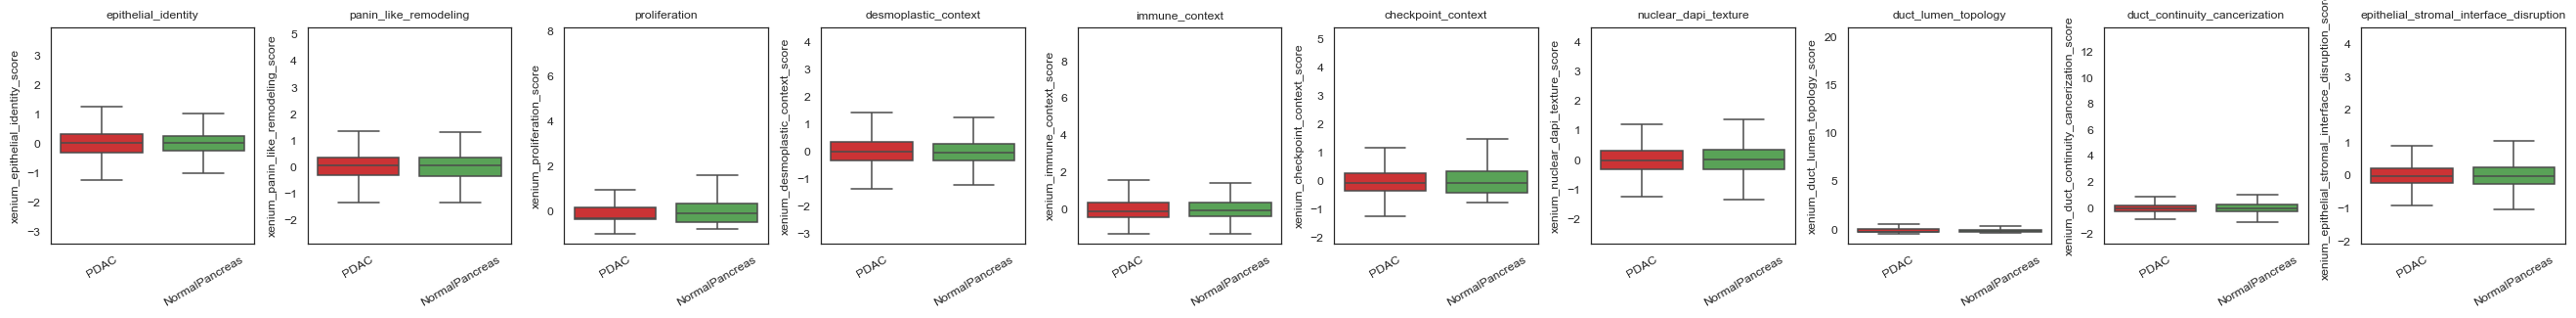

In [6]:

module_cols = [c for c in pooled_niche_feature_df.columns if c.startswith("xenium_") and c.endswith("_score")]

fig, axes = plt.subplots(1, len(module_cols), figsize=(2.4 * len(module_cols), 3), sharey=False)
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, module_cols):
    sns.boxplot(
        data=pooled_niche_feature_df,
        x="disease_group",
        y=col,
        hue="disease_group",
        palette={"NormalPancreas": "#4daf4a", "PDAC": "#e41a1c"},
        legend=False,
        fliersize=0,
        ax=ax,
    )
    ax.set_title(col.replace("xenium_", "").replace("_score", ""), fontsize=8)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(False)
plt.tight_layout()
plt.show()


## Feature Coverage Check Against PanIN/PDAC Morphology

The JCI review emphasizes that PanIN/PDAC progression involves architectural complexity, mucinous ductal programs, nuclear atypia, proliferation, and microenvironment remodeling. This table makes the Xenium feature coverage explicit so we do not over-claim what the dataset can measure.


In [7]:

feature_coverage_df = pd.DataFrame(
    [
        {
            "axis": "Ductal epithelial identity",
            "covered_now": True,
            "current_features": "EPCAM/KRT/SOX9/MUC/TFF/CEACAM/AGR expression programs when present",
            "missing_or_optional": "KRT19 is absent from some panels; membrane polarity markers from IMC are not available",
        },
        {
            "axis": "PanIN-like mucin/remodeling",
            "covered_now": True,
            "current_features": "MUC5AC, TFF1/2/3, CEACAM6, AGR2/3 expression plus epithelial component geometry",
            "missing_or_optional": "No manual PanIN grade labels yet; should be validated against H&E/ROI if available",
        },
        {
            "axis": "Nuclear atypia / shape",
            "covered_now": True,
            "current_features": "nucleus_area from cells table plus nucleus-boundary circularity, solidity, elongation, Feret diameter, irregularity",
            "missing_or_optional": "DAPI intensity/texture can now be extracted above; run full epithelial extraction before rebuilding niches to include it",
        },
        {
            "axis": "Apicobasal polarity / CK19-NaKATPase relationship",
            "covered_now": False,
            "current_features": "None",
            "missing_or_optional": "Requires multiplexed imaging membrane channels or aligned IF; Xenium transcript panel alone cannot reproduce this",
        },
        {
            "axis": "Architectural complexity",
            "covered_now": True,
            "current_features": "Boundary-proximity epithelial components, hull geometry, topology/skeleton features, duct/lumen topology, duct continuity proxies",
            "missing_or_optional": "2D section limitation remains; true 3D duct connectedness requires serial sections or registration",
        },
        {
            "axis": "Duct/lumen topology",
            "covered_now": True,
            "current_features": "Polygon-union hole/lumen fraction, lumen area, outer duct caliber, epithelial ring thickness, cystic dilation proxy",
            "missing_or_optional": "Depends on cell-boundary polygon quality; H&E would improve mucin/lumen interpretation",
        },
        {
            "axis": "Ductal continuity / cancerization",
            "covered_now": True,
            "current_features": "Component axis length/ratio, nearby epithelial components, nearest component distance, neighbor orientation alignment",
            "missing_or_optional": "This is a 2D local proxy for intraductal spread, not proof of clonal ductal migration",
        },
        {
            "axis": "Epithelial-stromal interface disruption",
            "covered_now": True,
            "current_features": "Union-boundary roughness, boundary length per area, nearby unassigned epithelial cells, immediate fibroblast contact from cell graph",
            "missing_or_optional": "Budding/extrusion calls are proxy features and should be spatially checked in representative regions",
        },
        {
            "axis": "Proliferation",
            "covered_now": True,
            "current_features": "MKI67/TOP2A/UBE2C/CENPF/CDK1 expression when present",
            "missing_or_optional": "Panel-dependent availability",
        },
        {
            "axis": "Desmoplastic/immune microenvironment",
            "covered_now": True,
            "current_features": "Surrounding Tier_A/Tier_B proportions and compartment marker summaries",
            "missing_or_optional": "Annotation should be reviewed using the notebook 01 QC plots before interpreting",
        },
    ]
)
feature_coverage_df


,axis,covered_now,current_features,missing_or_optional
0,Ductal epithelial identity,True,EPCAM/KRT/SOX9/MUC/TFF/CEACAM/AGR expression p...,KRT19 is absent from some panels; membrane pol...
1,PanIN-like mucin/remodeling,True,"MUC5AC, TFF1/2/3, CEACAM6, AGR2/3 expression p...",No manual PanIN grade labels yet; should be va...
2,Nuclear atypia / shape,True,nucleus_area from cells table plus nucleus-bou...,DAPI intensity/texture can now be extracted ab...
3,Apicobasal polarity / CK19-NaKATPase relationship,False,None,Requires multiplexed imaging membrane channels...
4,Architectural complexity,True,"Boundary-proximity epithelial components, hull...",2D section limitation remains; true 3D duct co...
5,Duct/lumen topology,True,"Polygon-union hole/lumen fraction, lumen area,...",Depends on cell-boundary polygon quality; H&E ...
6,Ductal continuity / cancerization,True,"Component axis length/ratio, nearby epithelial...",This is a 2D local proxy for intraductal sprea...
7,Epithelial-stromal interface disruption,True,"Union-boundary roughness, boundary length per ...",Budding/extrusion calls are proxy features and...
8,Proliferation,True,MKI67/TOP2A/UBE2C/CENPF/CDK1 expression when p...,Panel-dependent availability
9,Desmoplastic/immune microenvironment,True,Surrounding Tier_A/Tier_B proportions and comp...,Annotation should be reviewed using the notebo...
